In [1]:
%matplotlib inline

In [2]:
# Imports
import os
import pathlib
SALVUS_FLOW_SITE_NAME = os.environ.get("salome_remote") # Site name given in the installation of Salvus flow
PROJECT_DIR_VECTOR = "simulation_wavefield_output_larger"  
PROJECT_DIR_TENSOR = "simulation_wavefield_output_moment_tensor_bigger"  

# Add code to keep .gitignore updated to ignore salvus files
gitignore_path = pathlib.Path("..") / ".gitignore"
with open(gitignore_path, "r+") as f:
    contents = f.read()
    if PROJECT_DIR_VECTOR not in contents:
        f.write(f"\n{PROJECT_DIR_VECTOR }/\n")


import numpy as np
import salvus.namespace as sn
import xarray as xr
import salvus.namespace as sn
from salvus.project.tools.processing import block_processing
from salvus.toolbox.helpers.wavefield_output import (
    WavefieldOutput,
    wavefield_output_to_xarray,
)
import matplotlib.pyplot as plt
from matplotlib import animation
import obspy

# For wavefield output code
from salvus.mesh.unstructured_mesh_utils import read_model_from_h5
from salvus.toolbox.helpers import wavefield_output

#for plotting of wiggles, traces 
from scipy import signal

--> Server: 'https://l.mondaic.com/licensing_server', User: 'salome.bachmann', Group: 'ETHZ_ERDW_EEG'.
--> Negotiating 1 license instance(s) for 'SalvusMesh' [license version 1.0.0] for 1 seconds ...
--> Success! [Total duration: 0.70 seconds]


In [3]:
# Setup of the model domain as a box (same as research module)
domain_2d = sn.domain.dim2.BoxDomain(x0=0, x1=300, y0=0, y1=3)
p_v = sn.Project.from_domain(path=PROJECT_DIR_VECTOR, domain=domain_2d, load_if_exists=True)
p_t = sn.Project.from_domain(path=PROJECT_DIR_TENSOR, domain=domain_2d, load_if_exists=True)

Accordion(children=(HTML(value='\n                <head>\n                <style>\n                td {\n     …

[2026-04-02 15:55:39,886] INFO: Loading project from simulation_wavefield_output_larger.


Accordion(children=(HTML(value='\n                <head>\n                <style>\n                td {\n     …

[2026-04-02 15:55:39,904] INFO: Loading project from simulation_wavefield_output_moment_tensor_bigger.


In [4]:
# Extracting wavefield data
out_2d_layered_v = p_v.simulations.get_simulation_output_directory("sim_2d_layered", "event_wavefield_output")

vel_wo_layered_v = wavefield_output.WavefieldOutput.from_file(
    pathlib.Path(
        out_2d_layered_v,
        "volume_data_output.h5",
    ),
    "velocity",
    "volume",
)

# Converting to an x array
vel_2d_layered_v = wavefield_output.wavefield_output_to_xarray(
    vel_wo_layered_v,
    points=[np.linspace(0, 30, 101), np.linspace(0, 3, 101)],
)

out_2d_layered_t = p_t.simulations.get_simulation_output_directory("sim_2d_layered", "event_wavefield_output")

vel_wo_layered_t = wavefield_output.WavefieldOutput.from_file(
    pathlib.Path(
        out_2d_layered_t,
        "volume_data_output.h5",
    ),
    "velocity",
    "volume",
)

# Converting to an x array
vel_2d_layered_t = wavefield_output.wavefield_output_to_xarray(
    vel_wo_layered_t,
    points=[np.linspace(0, 30, 101), np.linspace(0, 3, 101)],
)

Finding enclosing elements (pass 1 of auto):   0%|          | 0/10201 [00:00<?, ?it/s]

Finding enclosing elements (pass 2 of auto):   0%|          | 0/6868 [00:00<?, ?it/s]

Finding enclosing elements (pass 3 of auto):   0%|          | 0/6868 [00:00<?, ?it/s]

Finding enclosing elements (pass 4 of auto):   0%|          | 0/6868 [00:00<?, ?it/s]

Finding enclosing elements (pass 5 of auto):   0%|          | 0/3434 [00:00<?, ?it/s]

...

Finding enclosing elements (pass 7 of auto):   0%|          | 0/3434 [00:00<?, ?it/s]

Finding enclosing elements (pass 8 of auto):   0%|          | 0/3434 [00:00<?, ?it/s]

Finding enclosing elements (pass 9 of auto):   0%|          | 0/3434 [00:00<?, ?it/s]

[2026-04-02 15:57:58,000] WARNING - salvus.mesh.algorithms.unstructured_mesh.utils: 3434 points were not claimed by enclosing elements. Depending on your use case, this may not be an issue.


Extracting wavefield to regular grid:   0%|          | 0/14 [00:00<?, ?it/s]

Finding enclosing elements (pass 1 of auto):   0%|          | 0/1001 [00:00<?, ?it/s]

Extracting wavefield to regular grid:   0%|          | 0/4 [00:00<?, ?it/s]

Finding enclosing elements (pass 1 of auto):   0%|          | 0/1001 [00:00<?, ?it/s]

Extracting wavefield to regular grid:   0%|          | 0/3 [00:00<?, ?it/s]

/tmp/ipykernel_3527535/4167251638.py:65: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


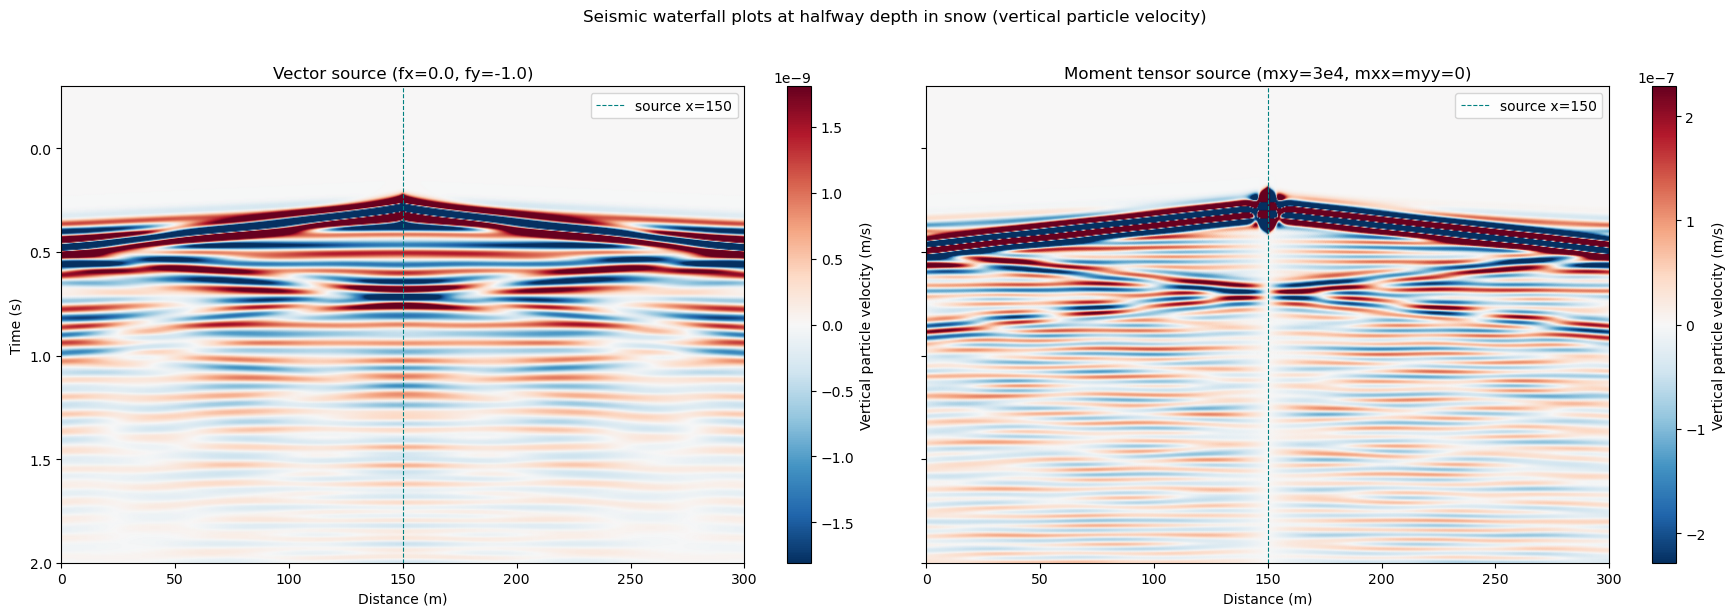

In [7]:
# Plotting the waterfall plots next to each other

# Define receiver line at snow-earth interface
y_surface = 3 * 2 / 3  # middle of snow layer
#y_surface = 3 * 1 / 3 # snow-air interface
x_line = np.linspace(0.0, 300.0, 1001)
y_line = np.full_like(x_line, y_surface)

# Extract wavefield along receiver line for vector source
vel_sg_v = wavefield_output.wavefield_output_to_xarray(
    vel_wo_layered_v,
    points=np.column_stack((x_line, y_line)),
)
sg_vy_v = vel_sg_v.isel(c=1)
t_vals_v = sg_vy_v.t.values
data_v = sg_vy_v.values  # shape: (n_t, n_points)
vmax_v = np.percentile(np.abs(data_v), 95)

# Extract wavefield along receiver line for moment tensor source
vel_sg_t = wavefield_output.wavefield_output_to_xarray(
    vel_wo_layered_t,
    points=np.column_stack((x_line, y_line)),
)
sg_vy_t = vel_sg_t.isel(c=1)
t_vals_t = sg_vy_t.t.values
data_t = sg_vy_t.values  # shape: (n_t, n_points)
vmax_t = np.percentile(np.abs(data_t), 95)

# Create one figure with two side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

im_v = axes[0].pcolormesh(
    x_line, t_vals_v, data_v,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=-vmax_v, vmax=vmax_v,
)
axes[0].invert_yaxis()
axes[0].axvline(x=150, color="teal", lw=0.8, linestyle="--", label="source x=150")
axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlim(0, 300)
axes[0].set_title("Vector source (fx=0.0, fy=-1.0)")
axes[0].legend()
fig.colorbar(im_v, ax=axes[0], label="Vertical particle velocity (m/s)")

im_t = axes[1].pcolormesh(
    x_line, t_vals_t, data_t,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=-vmax_t, vmax=vmax_t,
)
axes[1].axvline(x=150, color="teal", lw=0.8, linestyle="--", label="source x=150")
axes[1].set_xlabel("Distance (m)")
axes[1].set_xlim(0, 300)
axes[1].set_title("Moment tensor source (mxy=3e4, mxx=myy=0)")
axes[1].legend()
fig.colorbar(im_t, ax=axes[1], label="Vertical particle velocity (m/s)")

fig.suptitle(
    "Seismic waterfall plots at halfway depth in snow (vertical particle velocity)",
    y=1.02,
    fontsize=12,
)
plt.tight_layout()
plt.show()